# Precipitation with Elastic Energy

This example will cover adding a strain energy term to the KWN model. This strain energy term will also be used to calculate the aspect ratio as a function of precipitate radius.

## Example - The Cu-Ti system

In copper alloys with dilute amounts of titanium, formation of $\beta$-$Cu_4Ti$, a needle-like precipitate, can occur. Due to volume differences between the precipitate and the parent phase, the parent phase is put under strain. This strain comes with an elastic energy that serves to reduce the driving force for nucleation. In addition, the aspect ratio of the $\beta$ precipitates depends on the size of the precipitate to minimize the elastic and interfacial energy contributions.

To setup the KWN, the PrecipitateModel and BinaryThermodynamics will need to be defined. For BinaryThermodynamics, a mobility correction factor of 100 will be applied. This is to represent the presence of excess quench-in vacancies, which will speed up diffusion.

In [1]:
from kawin.thermo import BinaryThermodynamics

therm = BinaryThermodynamics('CuTi.tdb', ['CU', 'TI'], ['FCC_A1', 'CU4TI'], interfacialCompMethod='equilibrium', drivingForceMethod='approximate')
therm.setMobilityCorrection('all', 100)
therm.setGuessComposition(0.15)

## Model Inputs

For model inputs, the composition will be Cu-1.9Ti (at.%) and the temperature will be $350\text{ }^oC$. The molar volume of the matrix phase will be that of FCC copper with 2 atoms per unit cell. For the $\beta$-$Cu_4Ti$ precipitates, the atomic volume and atoms per unit cell are taken from Ref. 5 from the SpringerMaterials database. Bulk nucleation will be assumed with $1e30\text{ }sites/m^3$.

In [2]:
from kawin.precipitation import MatrixParameters, PrecipitateParameters

matrix = MatrixParameters(['TI'])
matrix.initComposition = 0.019
matrix.volume.setVolume(7.11e-6, 'VM', 4)
matrix.nucleationSites.setBulkDensity(1e30)

precipitate = PrecipitateParameters('CU4TI')
precipitate.gamma = 0.035
precipitate.volume.setVolume(0.25334e-27, 'VA', 20)
precipitate.nucleation.setNucleationType('bulk')

## Elastic Energy

Elastic energy has to be defined by a separate object, StrainEnergy. Here, the elastic constants and eigenstrains can be defined. It is important to check the order of the axes in the eigenstrains. For needle-like precipitates, the axes are (short axis, short axis, long axis). For plate-like precipitates, the axes are (long axis, long axis, short axis).

When inputting the StrainEnergy object into the KWN model, setting "calculateAspectRatio" to True will allow for the aspect ratio to be calculated from the elastic energy. Otherwise, the aspect ratio will be taken from what was defined when defining the precipitate shape.

In [3]:
precipitate.strainEnergy.setElasticConstants(168.4e9, 121.4e9, 75.4e9)
precipitate.strainEnergy.setEigenstrain([0.022, 0.022, 0.003])
precipitate.calculateAspectRatio = True

#Set precipitate shape
#Since we're calculating the aspect ratio, it does not have to be defined
#Otherwise, a constant value or function can be inputted
precipitate.shapeFactor.setPrecipitateShape('needle')

## Solving the model

In [4]:
from kawin.precipitation import PrecipitateModel

model = PrecipitateModel(matrix, precipitate, therm, 350+273.15)
model.solve(1e5, verbose=True, vIt=5000)

/Users/ury3/Desktop/codes/kawin/kawin/precipitation/NucleationRate.py:190: RuntimeWarning: divide by zero encountered in divide
  incubationTime = np.amin([np.exp(-tau[indices] / time), np.ones(tau[indices].shape)], axis=0)


N	Time (s)	Sim Time (s)	Temperature (K)	Matrix Comp
0	0.0e+00		0.0		623		1.9000

	Phase	Prec Density (#/m3)	Volume Frac	Avg Radius (m)	Driving Force (J/mol)
	CU4TI	0.000e+00		0.0000		0.0000e+00	1.9660e+03

N	Time (s)	Sim Time (s)	Temperature (K)	Matrix Comp
4127	1.0e+05		34.6		623		0.1758

	Phase	Prec Density (#/m3)	Volume Frac	Avg Radius (m)	Driving Force (J/mol)
	CU4TI	1.476e+23		9.3686		5.0967e-09	1.2302e+02



## Plotting

As with the other examples, plotting is the same. Some additional things:
1. The variable 'timeUnits' is set to 'min' to plot in minutes rather than seconds
2. The equilibrium matrix composition is plotted to compare with the actual composition.
3. The mean aspect ratio and aspect ratio as a function of radius is plotted

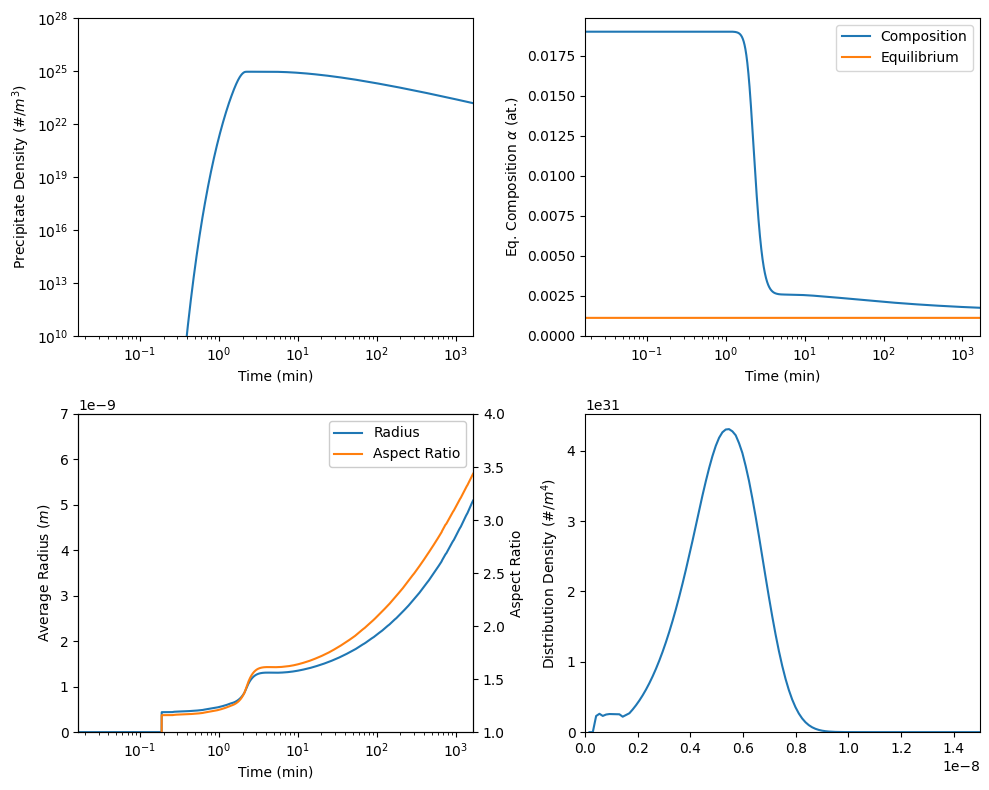

In [5]:
%matplotlib inline
import matplotlib.pyplot as plt
from kawin.precipitation.Plot import plotPrecipitateResults

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

plotPrecipitateResults(model, 'precipitate density', ax=axes[0,0], timeUnits='min')
axes[0,0].set_ylim([1e10, 1e28])
axes[0,0].set_yscale('log')

plotPrecipitateResults(model, 'composition', ax=axes[0,1], timeUnits='min', label='Composition')
plotPrecipitateResults(model, 'eq comp alpha', ax=axes[0,1], timeUnits='min', label='Equilibrium')
axes[0,1].legend()

plotPrecipitateResults(model, 'average radius', ax=axes[1,0], timeUnits='min', label='Radius', color='C0')
axes[1,0].set_ylim([0, 7e-9])
ax1 = axes[1,0].twinx()
plotPrecipitateResults(model, 'aspect ratio', ax=ax1, timeUnits='min', label='Aspect Ratio', color='C1')
ax1.set_ylim([1,4])

lineR, labelR = axes[1,0].get_legend_handles_labels()
lineAR, labelAR = ax1.get_legend_handles_labels()
axes[1,0].legend(lineR+lineAR, labelR+labelAR, framealpha=1)

plotPrecipitateResults(model, 'pdf', ax=axes[1,1])
axes[1,1].set_xlim([0, 1.5e-8])

fig.tight_layout()

## References

1. A. T. Dinsdale, "SGTE Data for Pure Elements" *Calphad* 15 (1991) p. 317
2. J. Wang et al, "Experimental Investigation and Thermodynamic Assessment of the Cu-Sn-Ti Ternary System" *Calphad* 35 (2011) p. 82
3. J. Wang et al, "Assessment of Atomic Mobilities in FCC Cu-Fe and CuTi Alloys" *Journal of Phase Equilibria and Diffusion* 32 (2011) p. 30
4. K. Wu, Q. Chen and P. Mason, "Simulation of Precipitate Kinetics with Non-Spherical Particles" *Journal of Phase Equilibria and Diffusion* 39 (2018) p. 571
5. Eremenko V.N., Buyanov Y.I., Prima S.B., "Phase diagram of the system titanium-copper" *Soviet Powder Metallurgy and Metal Ceramics* 5 (1966) p. 494